In [1]:
import nest_asyncio
nest_asyncio.apply()

In [2]:
import pyshark
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [3]:
pcap_path = "../captures/2.pcapng"
capture = pyshark.FileCapture(pcap_path, display_filter="icmp")

In [4]:
packets = []

for pkt in capture:
    try:
        packets.append({
            "time": float(pkt.sniff_timestamp),
            "src": pkt.ip.src,
            "dst": pkt.ip.dst,
            "type": str(pkt.icmp.type),
            "seq": str(pkt.icmp.seq)
        })
    except Exception:
        pass

capture.close()

df = pd.DataFrame(packets)
df.head()

,time,src,dst,type,seq
0,1.776503e+09,10.10.166.182,172.217.24.14,8,1
1,1.776503e+09,172.217.24.14,10.10.166.182,0,1
2,1.776503e+09,10.10.166.182,172.217.24.14,8,2
3,1.776503e+09,172.217.24.14,10.10.166.182,0,2
4,1.776503e+09,10.10.166.182,172.217.24.14,8,3


In [5]:
print("Shape:", df.shape)
print("\nICMP Types Count:")
print(df["type"].value_counts())

Shape: (129, 5)

ICMP Types Count:
type
8    75
0    54
Name: count, dtype: int64


In [6]:
requests = df[df["type"] == "8"].copy()   # Echo Request
replies = df[df["type"] == "0"].copy()    # Echo Reply

print("Requests:", len(requests))
print("Replies:", len(replies))

Requests: 75
Replies: 54


In [14]:
rtt_data = []

for _, req in requests.iterrows():
    match = replies[
        (replies["src"] == req["dst"]) &
        (replies["dst"] == req["src"]) &
        (replies["seq"] == req["seq"]) &
        (replies["time"] > req["time"])
    ]
    
    if not match.empty:
        rep = match.iloc[0]
        rtt = (rep["time"] - req["time"]) * 1000
        rtt_data.append({
            "destination": req["dst"],
            "rtt_ms": rtt
        })

rtt_df = pd.DataFrame(rtt_data)
rtt_df.head()

,destination,rtt_ms
0,172.217.24.14,6.430387
1,172.217.24.14,9.650707
2,172.217.24.14,4.999399
3,172.217.24.14,5.030870
4,104.16.132.229,37.217617


In [15]:
avg_rtt = rtt_df.groupby("destination")["rtt_ms"].mean().reset_index()
avg_rtt

,destination,rtt_ms
0,103.102.166.224,60.246992
1,104.16.132.229,39.125872
2,150.171.22.12,28.033352
3,150.171.28.10,27.694178
4,151.101.129.140,34.519482
5,17.253.144.10,31.894255
6,172.217.24.14,6.527841
7,172.64.154.211,25.846434
8,198.252.206.1,32.220936
9,20.207.73.82,36.958122


In [16]:
avg_rtt["destination"]

0     103.102.166.224
1      104.16.132.229
2       150.171.22.12
3       150.171.28.10
4     151.101.129.140
5       17.253.144.10
6       172.217.24.14
7      172.64.154.211
8       198.252.206.1
9        20.207.73.82
10        74.6.231.20
Name: destination, dtype: str

In [17]:
distance_map = {
    "103.102.166.224": 50,
    "104.16.132.229": 1800,
    "150.171.22.12": 2200,
    "150.171.28.10": 2200,
    "151.101.129.140": 2500,
    "17.253.144.10": 3000,
    "172.217.24.14": 1200,
    "172.64.154.211": 1800,
    "198.252.206.1": 3200,
    "20.207.73.82": 2500,
    "74.6.231.20": 8000
}

avg_rtt_df["distance_km"] = avg_rtt_df["destination_ip"].map(distance_map)
final_df = avg_rtt_df.dropna()
final_df

,destination_ip,avg_rtt_ms,distance_km
0,103.102.166.224,60.246992,50
1,104.16.132.229,39.125872,1800
2,150.171.22.12,28.033352,2200
3,150.171.28.10,27.694178,2200
4,151.101.129.140,34.519482,2500
5,17.253.144.10,31.894255,3000
6,172.217.24.14,6.527841,1200
7,172.64.154.211,25.846434,1800
8,198.252.206.1,32.220936,3200
9,20.207.73.82,36.958122,2500


In [18]:
X = final_df[["distance_km"]]
y = final_df["avg_rtt_ms"]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R² Score:", r2_score(y, y_pred))

Slope: 0.03222331475041164
Intercept: -28.96886527979168
R² Score: 0.748489886075832


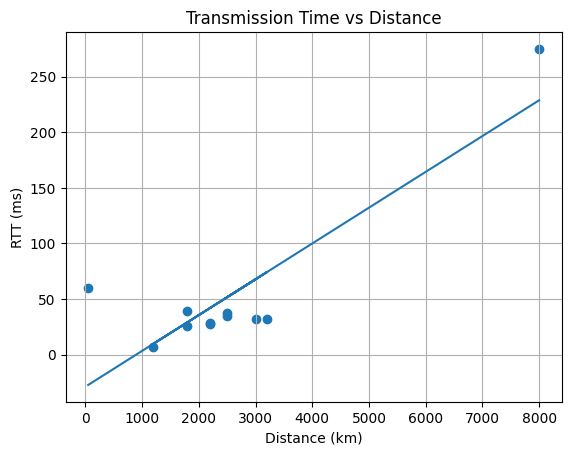

In [19]:
plt.scatter(X, y)
plt.plot(X, y_pred)
plt.xlabel("Distance (km)")
plt.ylabel("RTT (ms)")
plt.title("Transmission Time vs Distance")
plt.grid()
plt.show()

In [25]:
clean_df = final_df[final_df["avg_rtt_ms"] < 150]

In [26]:
X_clean = clean_df[["distance_km"]]
y_clean = clean_df["avg_rtt_ms"]

model.fit(X_clean, y_clean)

print("Clean R²:", r2_score(y_clean, model.predict(X_clean)))

Clean R²: 0.08936566428814163


In [27]:
final_df.to_csv("../data/rtt_dataset.csv", index=False)